<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/drive/1uLDVsgHnevEWvPQvXvQ-lcykSihO-DUr#scrollTo=jxD4udrdbbEE

# Experiment 7: Instance Segmentation using Deep Learning

---

##  Aim
To implement Instance Segmentation using a pre-trained deep learning model (Mask R-CNN) and understand how it differs from semantic segmentation.

---

##  Theory

### What is Instance Segmentation?

Instance Segmentation is the task of **detecting and delineating each distinct object** of interest appearing in an image at the pixel level.

It combines:
- **Object Detection** → Where is each object? (Bounding Box)
- **Semantic Segmentation** → What class does each pixel belong to?

The key difference:
| Task | What it does |
|------|-------------|
| Semantic Segmentation | Labels every pixel with a class (all people = one blob) |
| Instance Segmentation | Labels every pixel AND separates individual instances (person 1, person 2...) |

---

### Mask R-CNN: The Core Architecture

**Mask R-CNN** (He et al., 2017) is the most popular instance segmentation model. It extends Faster R-CNN by adding a **mask prediction branch** in parallel with the bounding box and class prediction branches.

#### Architecture Flow:
```
Input Image
     ↓
Backbone (ResNet-50 / ResNet-101)
     ↓
Feature Pyramid Network (FPN)
     ↓
Region Proposal Network (RPN) → Proposes candidate regions
     ↓
RoI Align → Precisely aligns features for each proposed region
     ↓
Three Parallel Heads:
  ├── Classification Head → What class is this object?
  ├── Bounding Box Head  → Where exactly is it? (refine box)
  └── Mask Head         → Pixel-wise binary mask for each instance
```

#### Key Component: RoI Align
Unlike RoI Pooling (used in Faster R-CNN), **RoI Align** uses bilinear interpolation to precisely map features without quantization errors. This is critical for accurate pixel-level masks.

#### Key Component: Mask Head
The mask head is a small **Fully Convolutional Network (FCN)** that takes the aligned features and outputs a **28×28 binary mask** for each class. During inference, the mask is resized to the bounding box dimensions.

---

### Feature Pyramid Network (FPN)

Different objects appear at different scales. FPN solves this by:
- Creating a **multi-scale feature pyramid** from the backbone
- Detecting small objects at high-resolution feature maps
- Detecting large objects at low-resolution (but semantically rich) feature maps

---

### Loss Function in Mask R-CNN

The total loss is a **multi-task loss**:

$$L = L_{cls} + L_{box} + L_{mask}$$

Where:
- $L_{cls}$ = Classification loss (cross-entropy)
- $L_{box}$ = Bounding box regression loss (smooth L1)
- $L_{mask}$ = Binary cross-entropy loss per pixel, per class

---

### Applications of Instance Segmentation
- Autonomous driving (pedestrians, vehicles, cyclists)
- Medical imaging (segmenting individual cells or lesions)
- Robotics (grasping specific objects)
- Satellite image analysis
- Industrial defect detection

---

##  Libraries Used
- `torchvision` — provides pre-trained Mask R-CNN
- `torch` — deep learning framework
- `PIL` / `OpenCV` — image loading and processing
- `matplotlib` — visualization
- `numpy` — numerical operations

---

## Step 1: Install and Import Required Libraries

In [18]:
# Install required libraries (run this if on fresh Colab)
# torchvision comes pre-installed on Colab, but let's ensure it
!pip install torch torchvision --quiet

In [19]:
# Import all necessary libraries
import torch                          # PyTorch: core deep learning framework
import torchvision                    # Vision-specific tools and pretrained models
import torchvision.transforms as T   # Image transformations
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Plotting
import matplotlib.patches as mpatches
from PIL import Image                # Image loading from file / URL
import requests                      # To download images from the web
from io import BytesIO               # To read bytes as file
import random                        # For color generation
import cv2                           # OpenCV for mask processing

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## Step 2: Load Pre-trained Mask R-CNN Model

**Theory:**  
We use a Mask R-CNN model **pre-trained on COCO dataset** (Common Objects in Context), which contains 80 object categories. Pre-training means the model has already learned to detect and segment common objects — we just use it directly for inference (no retraining needed).

Setting `model.eval()` puts the model in **inference mode** — this disables dropout and batch normalization updates that are only needed during training.

In [20]:
# Load the pre-trained Mask R-CNN model from torchvision
# weights='DEFAULT' loads the best available weights (pre-trained on COCO)
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')

# Move model to the available device (GPU or CPU)
model = model.to(device)

# Set to evaluation mode (not training mode)
# This disables dropout and makes batch norm use running statistics
model.eval()

print(" Mask R-CNN model loaded successfully!")
print("Model is on:", next(model.parameters()).device)

 Mask R-CNN model loaded successfully!
Model is on: cuda:0


## Step 3: Define COCO Class Labels

**Theory:**  
The COCO dataset has **80 object categories** (plus background = index 0). The model outputs a class index for each detected object. We map these indices back to human-readable names.

In [21]:
# COCO dataset class labels (80 categories + background at index 0)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print(f"Total classes (including background): {len(COCO_INSTANCE_CATEGORY_NAMES)}")
print(f"Example classes: {COCO_INSTANCE_CATEGORY_NAMES[1:10]}")

Total classes (including background): 81
Example classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


## Step 4: Load and Preprocess an Input Image

**Theory:**  
Deep learning models expect input in a specific format. For Mask R-CNN:
- Input must be a **list of tensors**, each of shape `[C, H, W]` (Channels, Height, Width)
- Pixel values must be in range **[0, 1]** (normalized)
- The model handles its own internal normalization via FPN

We download a sample street scene image and convert it to a tensor.

 Image loaded from URL. Size: (2048, 920)


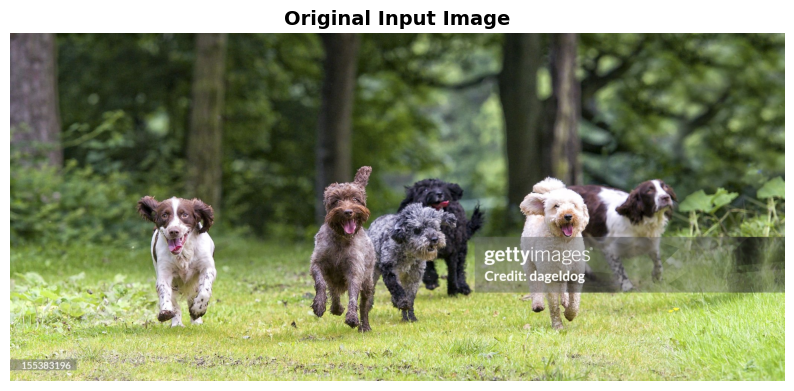

In [22]:
# Download a sample image from the internet (a street scene with people and vehicles)
# You can replace this URL with any public image URL
IMAGE_URL = "https://media.gettyimages.com/id/155383196/photo/here-come-the-girls.jpg?s=2048x2048&w=gi&k=20&c=20B02T-iQnKCMLTFE7KjoIQtQdrXPtECG2qdgy0vyX8="

try:
    # Fetch the image from URL
    response = requests.get(IMAGE_URL, timeout=10)
    img_pil = Image.open(BytesIO(response.content)).convert("RGB")
    print(f" Image loaded from URL. Size: {img_pil.size}")
except Exception as e:
    print(f"Could not load from URL: {e}")
    print("Creating a synthetic test image instead...")
    # Fallback: create a simple synthetic image
    img_array = np.random.randint(50, 200, (480, 640, 3), dtype=np.uint8)
    img_pil = Image.fromarray(img_array)

# Display the original image
plt.figure(figsize=(10, 6))
plt.imshow(img_pil)
plt.title("Original Input Image", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [23]:
# Transform the image to a tensor format that the model expects
# T.ToTensor() converts a PIL image (H x W x C, uint8) to
# a tensor (C x H x W, float32) and normalizes to [0, 1]
transform = T.ToTensor()

# Apply transformation
img_tensor = transform(img_pil)

# Move tensor to the same device as the model
img_tensor = img_tensor.to(device)

print(f"Image tensor shape: {img_tensor.shape}")
print(f"Pixel value range: [{img_tensor.min():.2f}, {img_tensor.max():.2f}]")
print("Format: [Channels, Height, Width]")

Image tensor shape: torch.Size([3, 920, 2048])
Pixel value range: [0.00, 1.00]
Format: [Channels, Height, Width]


## Step 5: Run Inference (Instance Segmentation)

**Theory:**  
During inference:
1. The image passes through the **backbone (ResNet-50)** to extract features
2. **FPN** creates multi-scale feature maps
3. **RPN** proposes region candidates
4. **RoI Align** extracts fixed-size features for each proposal
5. Three heads output: class label, bounding box, and a 28×28 binary mask

`torch.no_grad()` disables gradient computation during inference — we don't need gradients since we are not training, and this saves memory.

In [24]:
# Run inference on the image
# torch.no_grad() disables gradient tracking — saves memory and speeds up inference
with torch.no_grad():
    # Model expects a list of tensors (batch of images)
    predictions = model([img_tensor])

# predictions is a list of dicts, one per image
# For our single image, we take predictions[0]
pred = predictions[0]

print("Keys in prediction output:", list(pred.keys()))
print(f"\nNumber of detections: {len(pred['labels'])}")
print(f"Detected classes (raw indices): {pred['labels'].cpu().numpy()}")
print(f"Confidence scores: {pred['scores'].cpu().numpy().round(2)}")
print(f"Bounding boxes shape: {pred['boxes'].shape}")
print(f"Masks shape: {pred['masks'].shape}")

Keys in prediction output: ['boxes', 'labels', 'scores', 'masks']

Number of detections: 15
Detected classes (raw indices): [18 18 18 18 20 18 20 20 18 18 20 16 20 20 20]
Confidence scores: [1.   1.   0.99 0.96 0.85 0.83 0.6  0.46 0.43 0.2  0.2  0.14 0.12 0.1
 0.07]
Bounding boxes shape: torch.Size([15, 4])
Masks shape: torch.Size([15, 1, 920, 2048])


## Step 6: Filter Predictions by Confidence Threshold

**Theory:**  
The model returns ALL proposals above a minimal threshold. We apply a **confidence threshold** (e.g., 0.5 = 50%) to keep only high-confidence detections. Predictions below this are likely false positives.

In [25]:
# Set confidence threshold — only show detections above this score
CONFIDENCE_THRESHOLD = 0.5

# Filter all outputs using the threshold
scores = pred['scores'].cpu().numpy()           # Confidence scores for each detection
labels = pred['labels'].cpu().numpy()           # Class index for each detection
boxes = pred['boxes'].cpu().numpy()             # Bounding boxes [x1, y1, x2, y2]
masks = pred['masks'].cpu().numpy()             # Masks [N, 1, H, W] — probability masks

# Create boolean filter: keep detections with confidence > threshold
keep = scores >= CONFIDENCE_THRESHOLD

# Apply filter
scores_filtered = scores[keep]
labels_filtered = labels[keep]
boxes_filtered = boxes[keep]
masks_filtered = masks[keep]   # Each mask is [1, H, W] probability map

print(f"Total detections before filtering: {len(scores)}")
print(f"Detections after threshold ({CONFIDENCE_THRESHOLD}): {len(scores_filtered)}")
print("\nDetected objects:")
for i, (label, score) in enumerate(zip(labels_filtered, scores_filtered)):
    class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
    print(f"  Instance {i+1}: {class_name} (confidence: {score:.2f})")

Total detections before filtering: 15
Detections after threshold (0.5): 7

Detected objects:
  Instance 1: horse (confidence: 1.00)
  Instance 2: horse (confidence: 1.00)
  Instance 3: horse (confidence: 0.99)
  Instance 4: horse (confidence: 0.96)
  Instance 5: cow (confidence: 0.85)
  Instance 6: horse (confidence: 0.83)
  Instance 7: cow (confidence: 0.60)


## Step 7: Visualize Instance Segmentation Results

**Theory:**  
The mask output from Mask R-CNN is a **soft probability mask** (values 0–1 for each pixel). We convert it to a **binary mask** by thresholding at 0.5. Each instance gets a unique random color to distinguish it from other instances of the same class — this is the key visual difference from semantic segmentation.

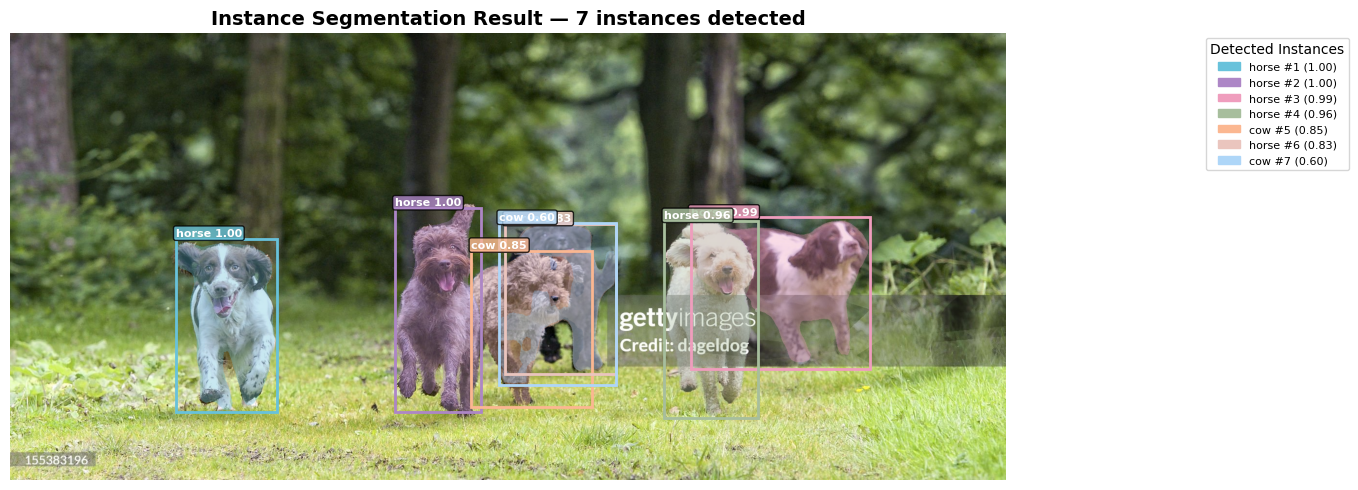

In [26]:
def get_random_color():
    """Generate a random bright color for visualizing each instance."""
    return [random.randint(100, 255), random.randint(100, 255), random.randint(100, 255)]

def draw_instance_segmentation(image_pil, boxes, masks, labels, scores, category_names, threshold=0.5):
    """
    Draw instance segmentation results on the image.
    - Each instance gets a unique color overlay
    - Bounding boxes and class labels are drawn
    """
    # Convert PIL image to numpy array for manipulation
    img_array = np.array(image_pil).copy()

    # Create an overlay image to blend masks onto
    overlay = img_array.copy()

    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.imshow(img_array)

    legend_patches = []

    for i in range(len(labels)):
        # Get a unique color for this instance
        color = get_random_color()

        # Convert the soft mask (probability) to a binary mask
        # masks[i] has shape [1, H, W] — squeeze to [H, W]
        soft_mask = masks[i, 0]          # Shape: [H, W], values in [0, 1]
        binary_mask = soft_mask > 0.5    # Convert to True/False

        # Apply colored overlay only where the mask is True
        for c in range(3):  # For R, G, B channels
            overlay[:, :, c] = np.where(
                binary_mask,
                overlay[:, :, c] * 0.5 + color[c] * 0.5,  # Blend color with original
                overlay[:, :, c]                            # Keep original elsewhere
            )

        # Draw bounding box
        x1, y1, x2, y2 = boxes[i]
        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor=[c/255 for c in color],
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add class label and confidence text
        class_name = category_names[labels[i]]
        text = f"{class_name} {scores[i]:.2f}"
        ax.text(
            x1, y1 - 5, text,
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=[c/255 for c in color], alpha=0.8)
        )

        # Create legend entry for this instance
        patch = mpatches.Patch(
            color=[c/255 for c in color],
            label=f"{class_name} #{i+1} ({scores[i]:.2f})"
        )
        legend_patches.append(patch)

    # Show the overlay image (original + colored masks)
    ax.imshow(overlay, alpha=0.7)

    # Add legend
    if legend_patches:
        ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
                 bbox_to_anchor=(1.35, 1), title="Detected Instances")

    ax.set_title(f"Instance Segmentation Result — {len(labels)} instances detected",
                fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Call the visualization function
draw_instance_segmentation(
    img_pil, boxes_filtered, masks_filtered,
    labels_filtered, scores_filtered,
    COCO_INSTANCE_CATEGORY_NAMES
)

## Step 8: Visualize Individual Masks

**Theory:**  
Each instance has its own binary mask. Let's visualize the masks for individual detected objects to understand what the mask head outputs. The soft probability mask (before thresholding) shows confidence at each pixel level.

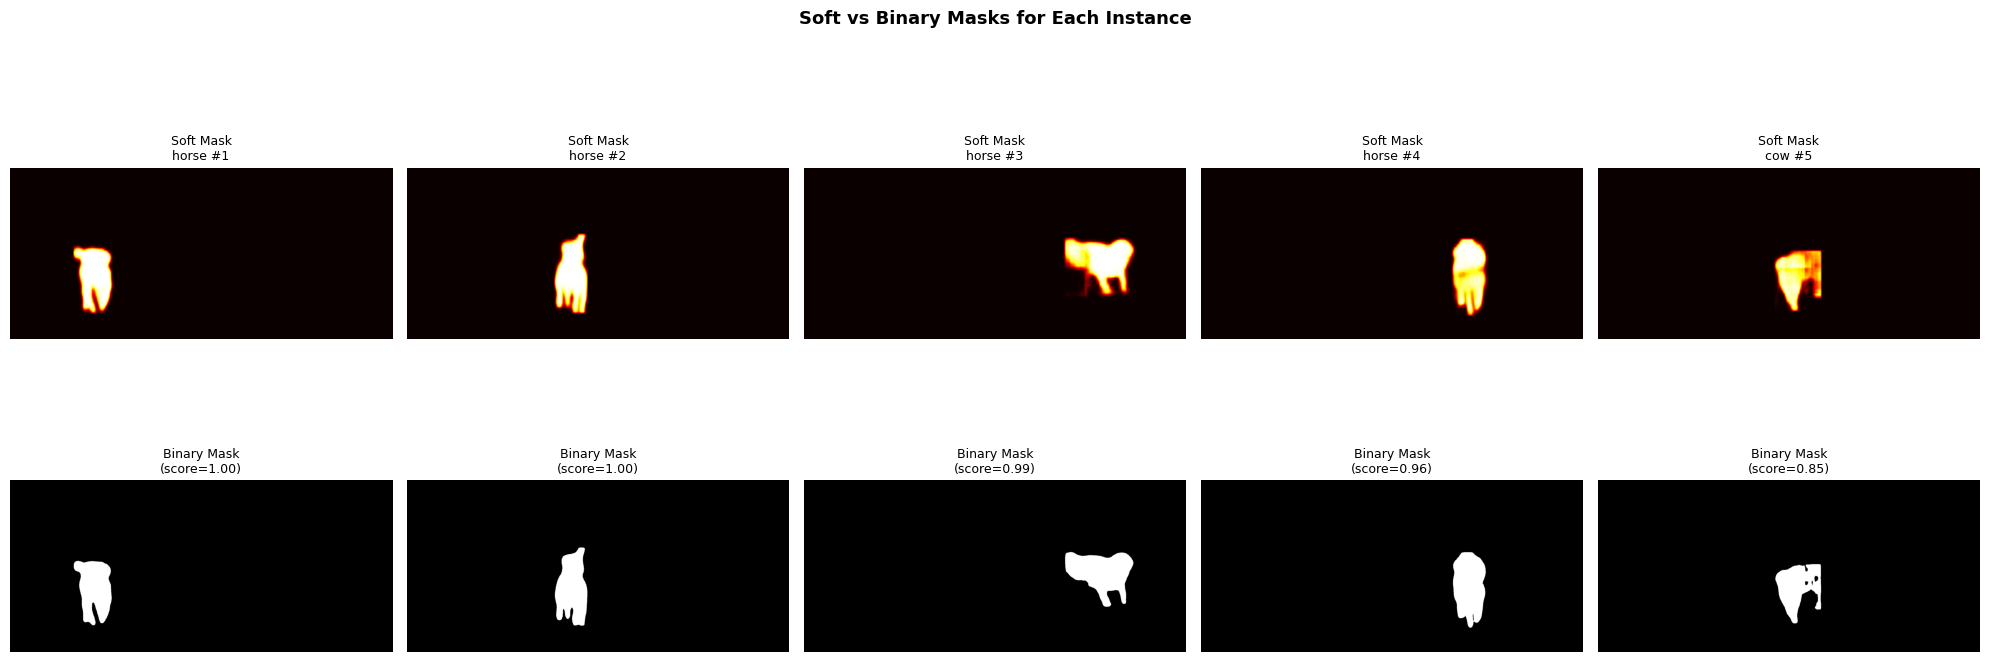


 Top Row: Soft probability masks (bright = high confidence pixel belongs to object)
 Bottom Row: Binary masks (thresholded at 0.5) — final segmentation output


In [27]:
# Show individual soft masks for the first few detected instances
num_show = min(5, len(masks_filtered))  # Show at most 5 instances

if num_show == 0:
    print("No instances detected above confidence threshold.")
else:
    fig, axes = plt.subplots(2, num_show, figsize=(4 * num_show, 8))

    # Handle the case where there is only 1 detection (axes won't be 2D)
    if num_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_show):
        class_name = COCO_INSTANCE_CATEGORY_NAMES[labels_filtered[i]]
        score = scores_filtered[i]

        # Row 1: Soft probability mask (raw output from mask head)
        soft = masks_filtered[i, 0]       # Shape [H, W]
        axes[0, i].imshow(soft, cmap='hot', vmin=0, vmax=1)
        axes[0, i].set_title(f"Soft Mask\n{class_name} #{i+1}", fontsize=9)
        axes[0, i].axis('off')

        # Row 2: Binary mask after thresholding at 0.5
        binary = soft > 0.5
        axes[1, i].imshow(binary, cmap='gray')
        axes[1, i].set_title(f"Binary Mask\n(score={score:.2f})", fontsize=9)
        axes[1, i].axis('off')

    fig.suptitle("Soft vs Binary Masks for Each Instance", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n Top Row: Soft probability masks (bright = high confidence pixel belongs to object)")
    print(" Bottom Row: Binary masks (thresholded at 0.5) — final segmentation output")

## Step 9: Compare Semantic vs Instance Segmentation

**Theory:**  
To understand the core difference, let's generate a **semantic segmentation map** from the instance segmentation output. In semantic segmentation, all instances of the same class share the same color/label. In instance segmentation, each object gets a unique identity.

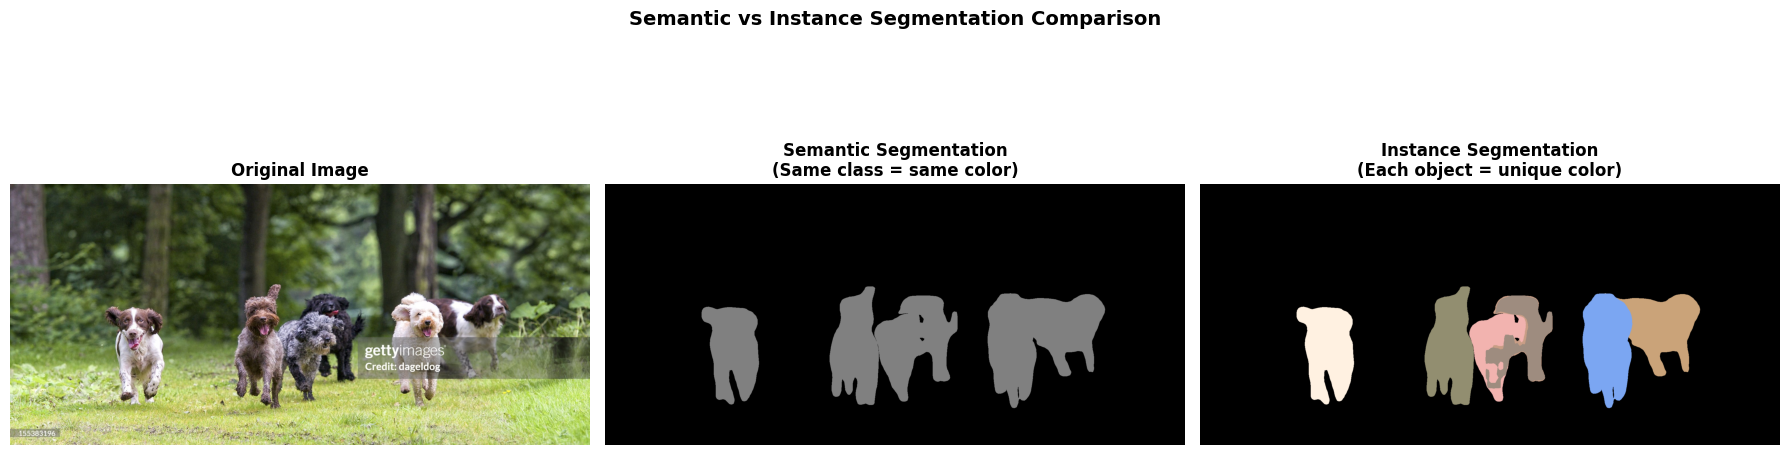


🔍 Observation:
  Semantic segmentation: All persons share the same red color — no individual distinction.
  Instance segmentation: Each person/car/object has a UNIQUE color — individual identification.


In [28]:
# Create a comparison: semantic-style vs instance-style visualization
img_np = np.array(img_pil)
H, W, _ = img_np.shape

# --- Semantic Segmentation Map (class-level, no distinction between instances) ---
semantic_map = np.zeros((H, W, 3), dtype=np.uint8)

# Define a fixed color per class
class_colors = {
    'person': [255, 0, 0],        # Red
    'car': [0, 255, 0],           # Green
    'bicycle': [0, 0, 255],       # Blue
    'dog': [255, 165, 0],         # Orange
    'cat': [128, 0, 128],         # Purple
    'motorcycle': [0, 255, 255],  # Cyan
    'bus': [255, 255, 0],         # Yellow
    'truck': [255, 20, 147],      # Pink
}
default_color = [128, 128, 128]   # Gray for other classes

# --- Instance Segmentation Map (each object gets unique color) ---
instance_map = np.zeros((H, W, 3), dtype=np.uint8)
instance_colors = []

for i in range(len(labels_filtered)):
    binary = masks_filtered[i, 0] > 0.5
    class_name = COCO_INSTANCE_CATEGORY_NAMES[labels_filtered[i]]

    # Semantic: use fixed class color
    sem_color = class_colors.get(class_name, default_color)
    for c in range(3):
        semantic_map[:, :, c][binary] = sem_color[c]

    # Instance: use unique random color per instance
    inst_color = get_random_color()
    instance_colors.append(inst_color)
    for c in range(3):
        instance_map[:, :, c][binary] = inst_color[c]

# Plot the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_np)
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(semantic_map)
axes[1].set_title("Semantic Segmentation\n(Same class = same color)", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(instance_map)
axes[2].set_title("Instance Segmentation\n(Each object = unique color)", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle("Semantic vs Instance Segmentation Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Observation:")
print("  Semantic segmentation: All persons share the same red color — no individual distinction.")
print("  Instance segmentation: Each person/car/object has a UNIQUE color — individual identification.")

## Step 10: Detection Statistics and Analysis

     INSTANCE SEGMENTATION RESULTS SUMMARY
Total instances detected: 7
Confidence threshold used: 0.5

Breakdown by class:
  horse               : 5 instance(s)
  cow                 : 2 instance(s)

Confidence scores for all detections:
  [1] horse           | Score: 0.999 | Box area: 74274 px²
  [2] horse           | Score: 0.995 | Box area: 74034 px²
  [3] horse           | Score: 0.993 | Box area: 114703 px²
  [4] horse           | Score: 0.965 | Box area: 78495 px²
  [5] cow             | Score: 0.852 | Box area: 79794 px²
  [6] horse           | Score: 0.832 | Box area: 70494 px²
  [7] cow             | Score: 0.596 | Box area: 79873 px²


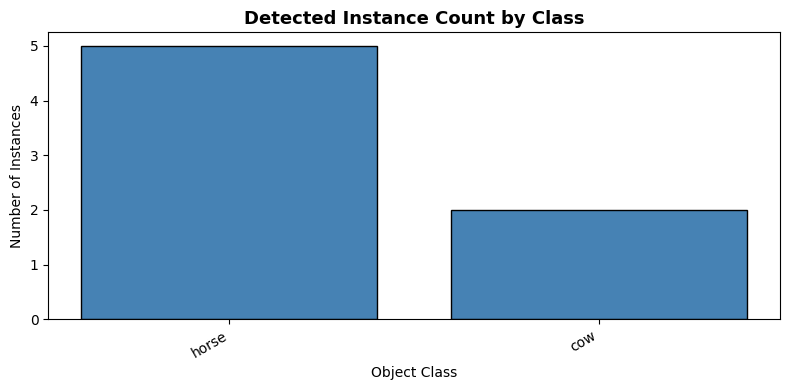

In [29]:
from collections import Counter

# Count how many instances of each class were detected
class_names_detected = [COCO_INSTANCE_CATEGORY_NAMES[l] for l in labels_filtered]
class_counts = Counter(class_names_detected)

print("=" * 50)
print("     INSTANCE SEGMENTATION RESULTS SUMMARY")
print("=" * 50)
print(f"Total instances detected: {len(labels_filtered)}")
print(f"Confidence threshold used: {CONFIDENCE_THRESHOLD}")
print()
print("Breakdown by class:")
for cls, count in class_counts.most_common():
    print(f"  {cls:<20}: {count} instance(s)")

print()
print("Confidence scores for all detections:")
for i, (cls, score, box) in enumerate(zip(class_names_detected, scores_filtered, boxes_filtered)):
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    print(f"  [{i+1}] {cls:<15} | Score: {score:.3f} | Box area: {int(area)} px²")

# Bar chart of class distribution
if class_counts:
    plt.figure(figsize=(8, 4))
    plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
    plt.title("Detected Instance Count by Class", fontsize=13, fontweight='bold')
    plt.xlabel("Object Class")
    plt.ylabel("Number of Instances")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Step 11: Try with Your Own Image

**Theory:**  
The model is general-purpose (trained on COCO). You can test it with any image containing common objects. Just replace the URL below with your own image URL.

Loaded from URL: https://media.gettyimages.com/id/107072782/photo/portrait-of-cats-and-dogs-sitting-together.jpg?s=2048x2048&w=gi&k=20&c=xMmRS0Kyek2IDUruxHv9KT2QvUt26OBhMBbQUkdMGtU=
Detected 10 instances above confidence 0.5


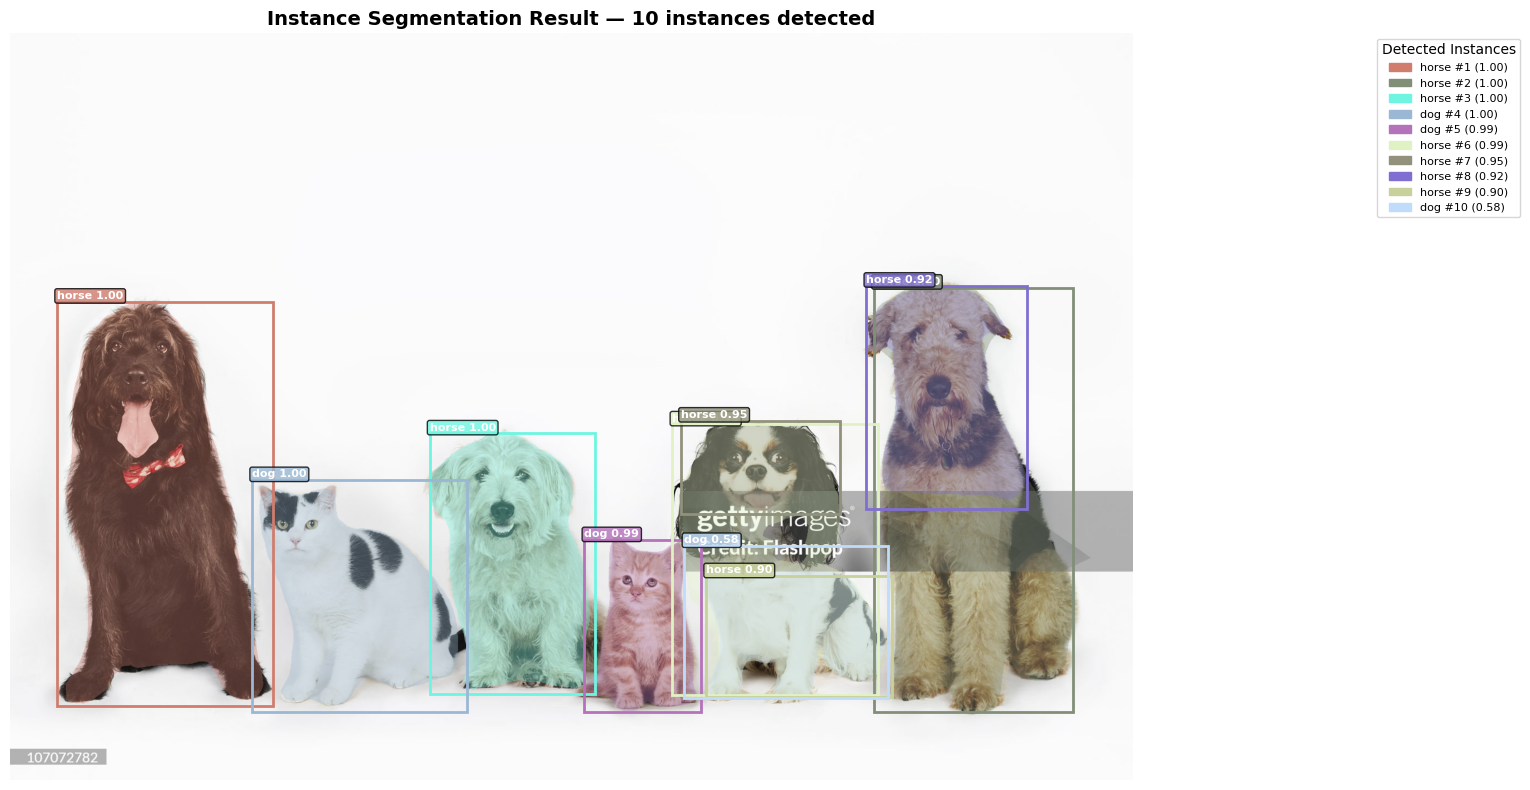

In [30]:
def run_instance_segmentation(image_url=None, image_path=None, confidence=0.5):
    """
    Full pipeline: load image → preprocess → infer → visualize.
    Use image_url for web images, or image_path for local files.
    """
    # ---- Load Image ----
    if image_url:
        response = requests.get(image_url, timeout=15)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        print(f"Loaded from URL: {image_url}")
    elif image_path:
        image = Image.open(image_path).convert("RGB")
        print(f"Loaded from path: {image_path}")
    else:
        print("Please provide image_url or image_path.")
        return

    # ---- Preprocess ----
    img_t = T.ToTensor()(image).to(device)

    # ---- Inference ----
    with torch.no_grad():
        preds = model([img_t])[0]

    # ---- Filter ----
    keep = preds['scores'].cpu().numpy() >= confidence
    boxes_f   = preds['boxes'].cpu().numpy()[keep]
    labels_f  = preds['labels'].cpu().numpy()[keep]
    scores_f  = preds['scores'].cpu().numpy()[keep]
    masks_f   = preds['masks'].cpu().numpy()[keep]

    print(f"Detected {len(labels_f)} instances above confidence {confidence}")

    # ---- Visualize ----
    draw_instance_segmentation(image, boxes_f, masks_f, labels_f, scores_f,
                                COCO_INSTANCE_CATEGORY_NAMES)

# ====== TRY WITH A DIFFERENT IMAGE ======
# Replace the URL below with any image you want
MY_IMAGE_URL = "https://media.gettyimages.com/id/107072782/photo/portrait-of-cats-and-dogs-sitting-together.jpg?s=2048x2048&w=gi&k=20&c=xMmRS0Kyek2IDUruxHv9KT2QvUt26OBhMBbQUkdMGtU="
run_instance_segmentation(image_url=MY_IMAGE_URL, confidence=0.5)

---

##  Results and Observations

1. **Mask R-CNN successfully detects individual instances** — each person, car, or object gets its own unique mask and bounding box.

2. **The soft masks show pixel-level probability** — areas with higher probability (brighter in heatmap) are more confidently inside the object.

3. **The key advantage over Semantic Segmentation** is the ability to differentiate between two people standing side by side — semantic segmentation would merge them into one blob, but instance segmentation gives each a separate mask.

4. **Confidence thresholding is critical** — a lower threshold gives more detections but with more false positives; a higher threshold gives fewer but more reliable detections.

---

##  Conclusion

In this experiment, we implemented **Instance Segmentation** using a **pre-trained Mask R-CNN** model with a ResNet-50 + FPN backbone. The model was trained on the COCO dataset and can detect and segment **80 different object categories** at the instance level.

Key takeaways:
- Mask R-CNN extends Faster R-CNN by adding a fully convolutional **mask head**
- **RoI Align** provides precise feature alignment for accurate masks
- The model outputs three things per instance: class label, bounding box, and pixel mask
- Instance segmentation is more powerful than semantic segmentation for counting or distinguishing individual objects
- Pre-trained models on large datasets (COCO) can be used out-of-the-box for general-purpose instance segmentation

---